In [18]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.steer_vec_loader import SteerVecLoader
from src.gram_matrix import compute_gram_matrix
from src.pair_strat import get_offdiag, make_pairs_df, stratify_pairs
from src.eda import run_eda

In [19]:
LAYER = 17
PATH = f"/Users/federicoscaffidimuta/Desktop/Third year/ML project/steering-vector-composition/results/layer_{LAYER}_vectors"

loader = SteerVecLoader(steer_vec_path=PATH, layer=LAYER)
loader.load_steer_vecs()
behavior_vecs, behaviors = loader.to_matrix()

In [20]:
behavior_matrix = behavior_vecs.shape
print(f"Behavior matrix shape: {behavior_matrix}")

vec_shape = behavior_vecs.shape[0]
print(f"Number of vectors is N = {vec_shape}")

expected_shape = (12, 4096)

G = compute_gram_matrix(behavior_vecs, expected_shape)  # compute gram matrix
print(f"Gram matrix shape is {G.shape}")

Behavior matrix shape: (12, 4096)
Number of vectors is N = 12
Gram matrix shape is (12, 12)


In [21]:
pairs_df = make_pairs_df(G, behaviors)  # get pairs dataframe
pairs_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine
0,0,1,sycophancy,refusal,0.127842,0.127842
1,0,2,sycophancy,hallucination,0.323904,0.323904
2,0,3,sycophancy,power_seeking,0.093350,0.093350
3,0,4,sycophancy,myopia,0.007897,0.007897
4,0,5,sycophancy,verbosity,0.019255,0.019255
5,0,6,sycophancy,formality,-0.103064,0.103064
6,0,7,sycophancy,politeness,-0.008216,0.008216
7,0,8,sycophancy,confidence,0.204391,0.204391
8,0,9,sycophancy,humor,0.083649,0.083649
9,0,10,sycophancy,agreeableness,0.086040,0.086040


In [22]:
strat_df = stratify_pairs(pairs_df)
strat_df.head(n=40)

[WARN] stratum 'moderate' has 8 pairs, wanted 13
[WARN] stratum 'high' has 0 pairs, wanted 13


,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum
0,0,1,sycophancy,refusal,0.127842,0.127842,near
1,0,7,sycophancy,politeness,-0.008216,0.008216,near
2,4,7,myopia,politeness,-0.028038,0.028038,near
3,1,7,refusal,politeness,0.068781,0.068781,near
4,6,7,formality,politeness,0.018243,0.018243,near
5,8,9,confidence,humor,0.029676,0.029676,near
6,4,10,myopia,agreeableness,0.191925,0.191925,near
7,3,5,power_seeking,verbosity,0.026149,0.026149,near
8,6,9,formality,humor,-0.044354,0.044354,near
9,1,6,refusal,formality,0.159216,0.159216,near


=== Summary statistics (all pairs) ===
                        value
n_pairs             66.000000
mean                 0.043548
std                  0.126745
min                 -0.271593
max                  0.338269
mean_abs             0.101349
std_abs              0.086950
near (<0.2)         58.000000
moderate [0.2,0.5)   8.000000
high (>=0.5)         0.000000

=== Most similar pairs ===
   behavior_i    behavior_j    cosine  abs_cosine
   sycophancy          evil  0.338269    0.338269
   sycophancy hallucination  0.323904    0.323904
hallucination          evil  0.323242    0.323242
    verbosity         humor  0.288917    0.288917
   politeness    confidence -0.271593    0.271593

=== Most orthogonal pairs ===
   behavior_i behavior_j    cosine  abs_cosine
hallucination  verbosity -0.000069    0.000069
      refusal       evil  0.001533    0.001533
agreeableness       evil -0.004227    0.004227
power_seeking confidence -0.005645    0.005645
      refusal  verbosity  0.005753   

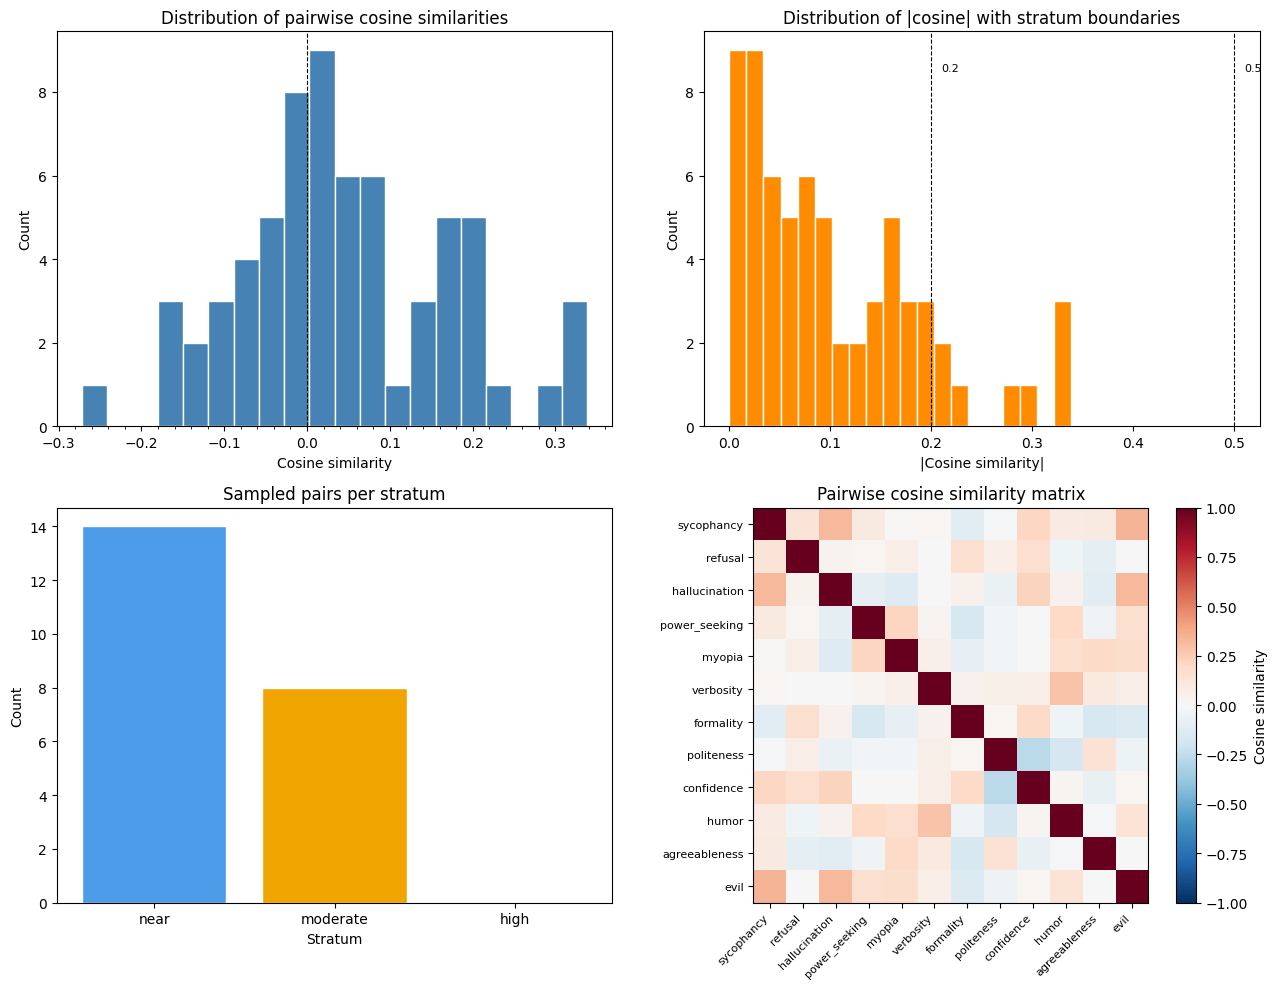

In [23]:
run_eda(pairs_df=pairs_df, strat_df=strat_df, behaviors=behaviors)